# Operations and Sales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel ("Financial_Consume_Complaints_clean.xlsx")
df.head(10)

,Complaint ID,Date Sumbited,Product,Sub-product,Issue,Sub-issue,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date Received,Company response to consumer,Timely response?,Consumer disputed?
0,2824926,2018-02-24,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company public response,Cumulus Financial,FL,33179,Tags,Consent not provided,Web,2018-02-24,Closed with explanation,Yes,No
1,1515991,2015-08-12,Debt collection,Credit card,Improper contact or sharing of info,Contacted employer after asked not to,Company public response,Cumulus Financial,CA,93561,Tags,Consent not provided,Web,2015-08-12,Closed with explanation,Yes,No
2,1145261,2014-12-05,Bank account or service,Checking account,Deposits and withdrawals,Contacted employer after asked not to,Company public response,Cumulus Financial,CA,91792,Tags,Consent not provided,Referral,2014-12-08,Closed with explanation,Yes,No
3,2573763,2017-07-13,Mortgage,Conventional home mortgage,Trouble during payment process,Contacted employer after asked not to,Company has responded to the consumer and the ...,Cumulus Financial,CA,92629,Tags,Consent not provided,Web,2017-07-13,Closed with explanation,Yes,No
4,2573113,2017-07-13,Mortgage,Conventional home mortgage,Struggling to pay mortgage,Contacted employer after asked not to,Company has responded to the consumer and the ...,Cumulus Financial,NY,10016,Tags,Consent not provided,Web,2017-07-13,Closed with explanation,Yes,No
5,2406037,2017-03-27,Credit card,Conventional home mortgage,Billing disputes,Contacted employer after asked not to,Company has responded to the consumer and the ...,Cumulus Financial,AZ,85323,Tags,Consent not provided,Referral,2017-03-27,Closed with explanation,Yes,No
6,2395777,2017-03-20,Debt collection,Mortgage,Cont'd attempts collect debt not owed,Debt resulted from identity theft,Company has responded to the consumer and the ...,Cumulus Financial,GA,30519,Tags,Consent not provided,Referral,2017-03-21,Closed with explanation,Yes,No
7,2850771,2018-03-19,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,Company has responded to the consumer and the ...,Cumulus Financial,NV,89048,Tags,Consent not provided,Referral,2018-03-21,Closed with monetary relief,Yes,No
8,2376685,2017-03-07,Mortgage,Other mortgage,Settlement process and costs,Deposits and withdrawals,Company has responded to the consumer and the ...,Cumulus Financial,AZ,85254,Older American,Consent not provided,Web,2017-03-07,Closed with explanation,Yes,No
9,2825857,2018-02-26,Credit card or prepaid card,Store credit card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Cumulus Financial,PA,16066,Older American,Consent not provided,Web,2018-02-26,Closed with non-monetary relief,Yes,No


In [3]:
df.shape

(75513, 17)

# Where are complaints concentrated?

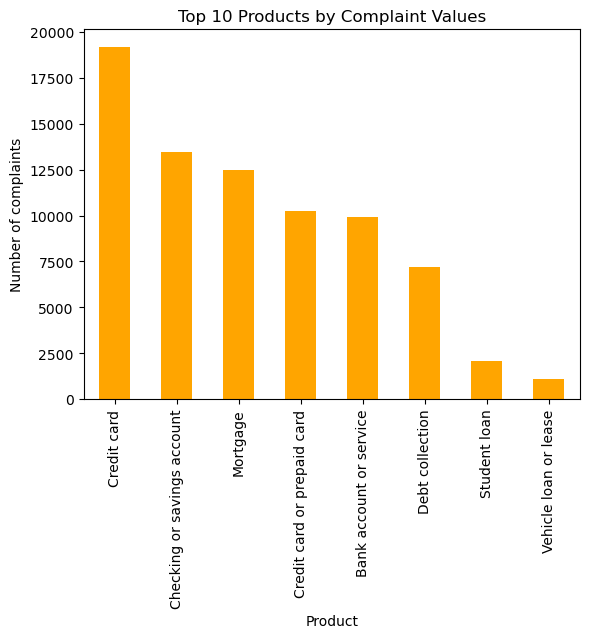

<Figure size 640x480 with 0 Axes>

In [6]:
df["Product"].value_counts().head(10).plot(kind="bar",color='orange')
plt.title("Top 10 Products by Complaint Values")
plt.xlabel("Product")
plt.ylabel("Number of complaints")
plt.figure()
plt.show()

### Inference

# What are the most common complaint issues (root causes)?

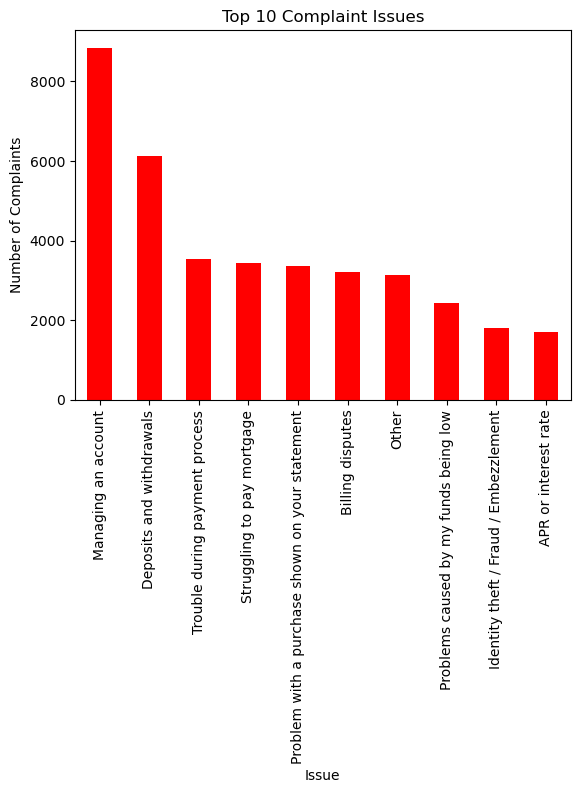

In [7]:
plt.figure()
df["Issue"].value_counts().head(10).plot(kind="bar",color='red')
plt.title("Top 10 Complaint Issues")
plt.xlabel("Issue")
plt.ylabel("Number of Complaints")
plt.show()


### Inference

# How do customer complaints change over time?

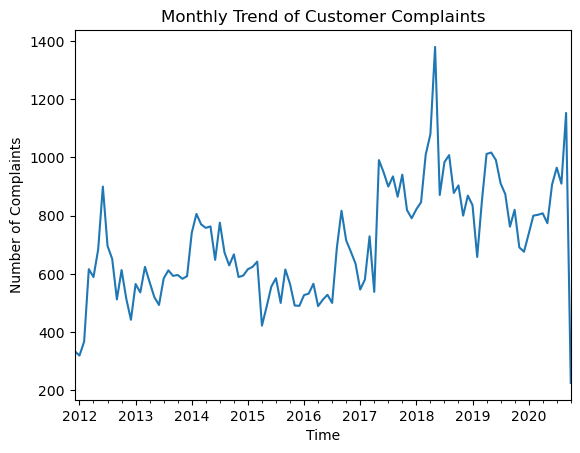

In [8]:
df["YearMonth"] = df["Date Received"].dt.to_period("M")

monthly_trend = df.groupby("YearMonth").size()

plt.figure()
monthly_trend.plot()
plt.title("Monthly Trend of Customer Complaints")
plt.xlabel("Time")
plt.ylabel("Number of Complaints")
plt.show()


### Inferences

# How effectively are customer complaints being resolved on time?

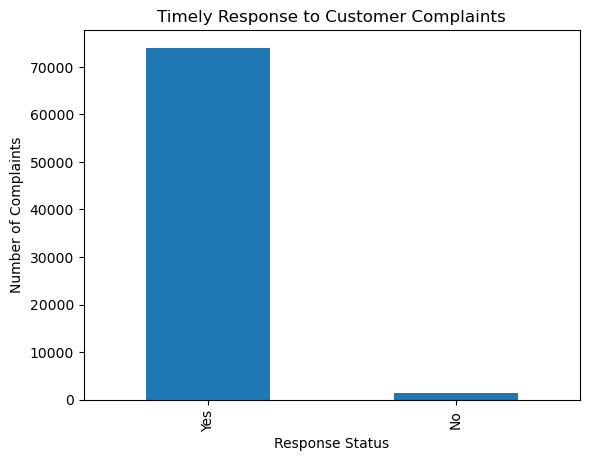

In [9]:
plt.figure()
df["Timely response?"].value_counts().plot(kind="bar")
plt.title("Timely Response to Customer Complaints")
plt.xlabel("Response Status")
plt.ylabel("Number of Complaints")
plt.show()


### Inferences

# Product vs Timely Response

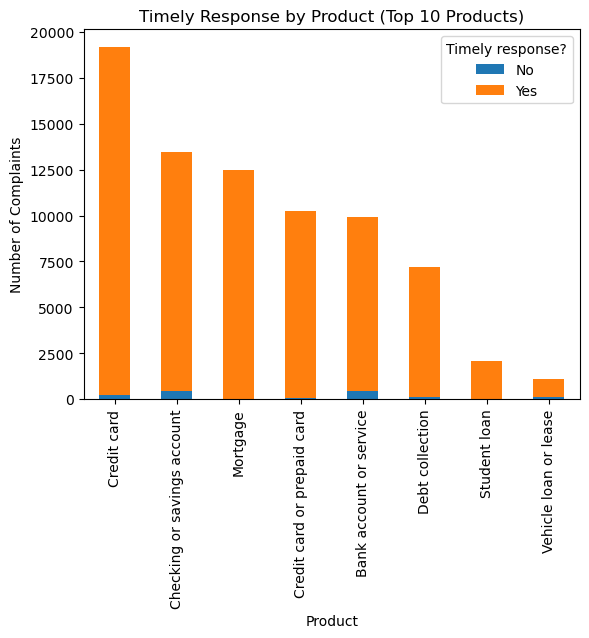

In [10]:
sla_product = pd.crosstab(
    df["Product"],
    df["Timely response?"]
)

sla_product_top = sla_product.loc[
    df["Product"].value_counts().head(10).index
]

sla_product_top.plot(kind="bar", stacked=True)
plt.title("Timely Response by Product (Top 10 Products)")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.show()

### Inference